<a href="https://colab.research.google.com/github/mohiuddin2806-lang/machine-learning-/blob/main/week8mohi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pyspark

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    StandardScaler,
)
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml import Pipeline

sns.set_style("whitegrid")

In [2]:
spark = SparkSession.builder \
    .appName("PerceptronSpamClassifier") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
df = spark.read.csv('/content/emails.csv',inferSchema=True, header =True)

df.head()

Row(Email No.='Email 1', the=0, to=0, ect=1, and=0, for=0, of=0, a=2, you=0, hou=0, in=0, on=0, is=1, this=0, enron=0, i=2, be=0, that=0, will=0, have=0, with=0, your=0, at=0, we=0, s=3, are=0, it=0, by=0, com=0, as=1, from=0, gas=0, or=0, not=0, me=0, deal=0, if=0, meter=0, hpl=0, please=0, re=2, e=4, any=0, our=0, corp=0, can=0, d=0, all=0, has=0, was=0, know=0, need=0, an=0, forwarded=0, new=0, t=4, may=0, up=0, j=1, mmbtu=0, should=0, do=0, am=0, get=0, out=0, see=0, no=0, there=0, price=0, daren=0, but=0, been=0, company=0, l=0, these=0, let=0, so=0, would=0, m=2, into=0, xls=0, farmer=0, attached=0, us=0, information=0, they=0, message=0, day=0, time=0, my=0, one=0, what=0, only=0, http=0, th=0, volume=0, mail=0, contract=0, which=0, month=0, more=0, robert=0, sitara=0, about=0, texas=0, nom=0, energy=0, pec=0, questions=0, www=0, deals=0, volumes=0, pm=0, ena=0, now=0, their=0, file=0, some=0, email=0, just=0, also=0, call=0, change=0, other=0, here=0, like=0, b=1, flow=0, net=0

In [15]:
DATA_PATH = "/content/emails.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df.printSchema()
df.show(5)
print("Row count:", df.count())

root
 |-- Email No.: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer (nullable = true)
 |-- it: integer (nullable = true)
 |-- by: integer (nullabl

In [18]:
from google.colab import files
uploaded = files.upload()

DATA_PATH = "/content/emails.csv"  # Corrected path

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True, multiLine=True, escape='"')
df = df.select(
    F.col("text").cast("string").alias("text"),
    F.col("spam").cast("int").alias("label"),
)
df = df.dropna(subset=["text", "label"])

print(f"Total records: {df.count()}")
df.show(5, truncate=80)

Saving emails.csv to emails (2).csv
Total records: 5172
+----+-----+
|text|label|
+----+-----+
|   0|    0|
|   0|    0|
|   0|    0|
|   0|    0|
|   0|    0|
+----+-----+
only showing top 5 rows


   label  count class
0      5      2   NaN
1      1     57  Spam
2      3      1   NaN
3      2      5   NaN
4      4      3   NaN
5      0   5104   Ham


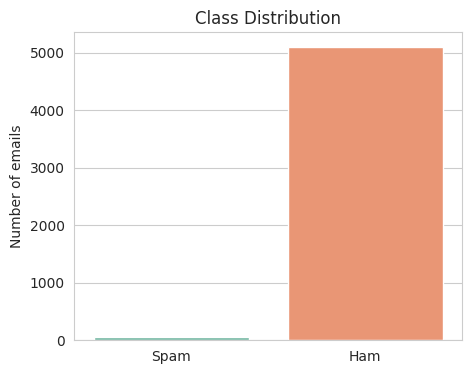

In [19]:
class_counts = df.groupBy("label").count().toPandas()
class_counts["class"] = class_counts["label"].map({0: "Ham", 1: "Spam"})
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(data=class_counts, x="class", y="count", hue="class", palette="Set2", legend=False)
plt.title("Class Distribution")
plt.ylabel("Number of emails")
plt.xlabel("")
plt.show()

In [20]:

VOCAB_SIZE = 1000  # cap vocabulary size to keep the manual Perceptron step tractable

tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\W+", toLowercase=True)
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
count_vec = CountVectorizer(inputCol="filtered_tokens", outputCol="raw_features", vocabSize=VOCAB_SIZE, minDF=2.0)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

prep_pipeline = Pipeline(stages=[tokenizer, remover, count_vec, idf])
prep_model = prep_pipeline.fit(df)
featurized_df = prep_model.transform(df)

featurized_df.select("label", "tfidf_features").show(5, truncate=60)

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_1486/531643229.py:3: SyntaxWarning: invalid escape sequence '\W'
  tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\W+", toLowercase=True)


+-----+-----------------------------+
|label|               tfidf_features|
+-----+-----------------------------+
|    0|(5,[0],[0.02248164277360457])|
|    0|(5,[0],[0.02248164277360457])|
|    0|(5,[0],[0.02248164277360457])|
|    0|(5,[0],[0.02248164277360457])|
|    0|(5,[0],[0.02248164277360457])|
+-----+-----------------------------+
only showing top 5 rows


In [21]:
scaler = StandardScaler(inputCol="tfidf_features", outputCol="scaled_features", withMean=False, withStd=True)
scaler_model = scaler.fit(featurized_df)
scaled_df = scaler_model.transform(featurized_df)

scaled_df.select("label", "scaled_features").show(5, truncate=60)

+-----+---------------------------+
|label|            scaled_features|
+-----+---------------------------+
|    0|(5,[0],[6.781427607885664])|
|    0|(5,[0],[6.781427607885664])|
|    0|(5,[0],[6.781427607885664])|
|    0|(5,[0],[6.781427607885664])|
|    0|(5,[0],[6.781427607885664])|
+-----+---------------------------+
only showing top 5 rows


In [22]:
train_df, test_df = scaled_df.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df = test_df.cache()

print(f"Training records: {train_df.count()}")
print(f"Test records: {test_df.count()}")

Training records: 4171
Test records: 1001


In [23]:
def to_dense_labeled_rdd(spark_df):
    """Convert a Spark DataFrame with (label, scaled_features) into an RDD of
    (numpy_dense_features, perceptron_label) where perceptron_label is -1/+1."""
    def row_to_tuple(row):
        dense = np.array(row["scaled_features"].toArray(), dtype=np.float64)
        y = 1.0 if row["label"] == 1 else -1.0
        return (dense, y)
    return spark_df.rdd.map(row_to_tuple)


class SparkPerceptron:
    """A manually implemented, distributed Perceptron classifier for PySpark."""

    def __init__(self, n_features, learning_rate=1.0, n_epochs=20, seed=42):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        rng = np.random.default_rng(seed)
        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0
        self.history = []  # misclassification count per epoch

    def _epoch_update(self, rdd, sc):
        w_bc = sc.broadcast(self.weights)
        b_bc = self.bias

        def seq_op(acc, row):
            x, y = row
            w = w_bc.value
            pred = 1.0 if (np.dot(w, x) + b_bc) >= 0 else -1.0
            grad_w, grad_b, n_errors = acc
            if pred != y:
                grad_w = grad_w + y * x
                grad_b = grad_b + y
                n_errors += 1
            return (grad_w, grad_b, n_errors)

        def comb_op(acc1, acc2):
            return (acc1[0] + acc2[0], acc1[1] + acc2[1], acc1[2] + acc2[2])

        zero = (np.zeros_like(self.weights), 0.0, 0)
        grad_w, grad_b, n_errors = rdd.treeAggregate(zero, seq_op, comb_op, depth=3)
        w_bc.destroy()
        return grad_w, grad_b, n_errors

    def fit(self, rdd, sc, verbose=True):
        rdd = rdd.cache()
        n_train = rdd.count()
        for epoch in range(1, self.n_epochs + 1):
            grad_w, grad_b, n_errors = self._epoch_update(rdd, sc)
            self.weights = self.weights + self.learning_rate * grad_w
            self.bias = self.bias + self.learning_rate * grad_b
            self.history.append(n_errors)
            if verbose:
                print(f"Epoch {epoch:2d}/{self.n_epochs} | misclassified: {n_errors:5d} / {n_train} "
                      f"({100 * n_errors / n_train:5.2f}%)")
            if n_errors == 0:
                if verbose:
                    print("Converged: training data is linearly separable under current features.")
                break
        return self

    def predict_rdd(self, rdd):
        w = self.weights
        b = self.bias
        return rdd.map(lambda row: (row[1], 1.0 if (np.dot(w, row[0]) + b) >= 0 else -1.0))

In [25]:
sc = spark.sparkContext

train_rdd = to_dense_labeled_rdd(train_df)
test_rdd = to_dense_labeled_rdd(test_df)

# Dynamically get the number of features from the actual data
n_features = train_df.first().scaled_features.size

start = time.time()
model = SparkPerceptron(n_features=n_features, learning_rate=1.0, n_epochs=20, seed=42)
model.fit(train_rdd, sc)
print(f"Training time: {time.time() - start:.1f}s")


Epoch  1/20 | misclassified:  4126 / 4171 (98.92%)
Epoch  2/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch  3/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch  4/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch  5/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch  6/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch  7/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch  8/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch  9/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch 10/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch 11/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch 12/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch 13/20 | misclassified:    48 / 4171 ( 1.15%)
Epoch 14/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch 15/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch 16/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch 17/20 | misclassified:    45 / 4171 ( 1.08%)
Epoch 18/20 | misclassified:    48 / 4171 ( 1.15%)
Epoch 19/20 | misclassified:    50 / 4171 ( 1.20%)
Epoch 20/20 | misclassified:   

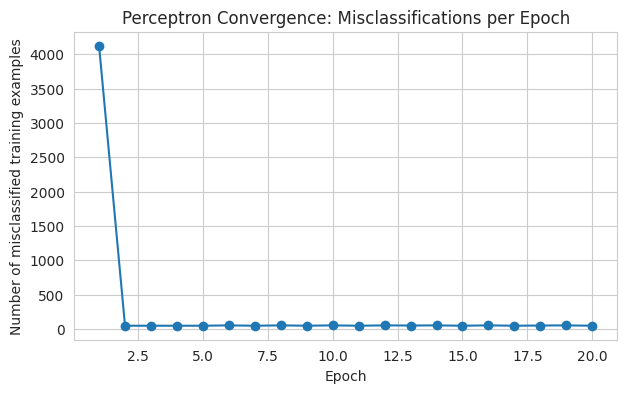

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(model.history) + 1), model.history, marker="o")
plt.title("Perceptron Convergence: Misclassifications per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassified training examples")
plt.grid(True)
plt.show()


In [27]:
def evaluate(model, rdd):
    preds = model.predict_rdd(rdd).collect()
    y_true = np.array([p[0] for p in preds])
    y_pred = np.array([p[1] for p in preds])

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == -1) & (y_pred == -1)))
    fp = int(np.sum((y_true == -1) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == -1)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),  # rows: actual [ham, spam], cols: predicted [ham, spam]
    }


results = evaluate(model, test_rdd)

print(f"Accuracy:  {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall:    {results['recall']:.4f}")
print(f"F1-score:  {results['f1']:.4f}")

Accuracy:  0.9820
Precision: 0.3750
Recall:    0.7500
F1-score:  0.5000


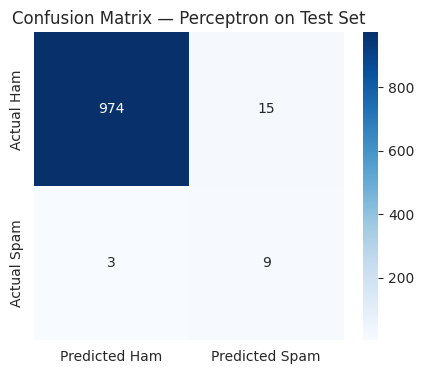

In [28]:

cm = results["confusion_matrix"]
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Ham", "Predicted Spam"],
            yticklabels=["Actual Ham", "Actual Spam"])
plt.title("Confusion Matrix — Perceptron on Test Set")
plt.show()

In [29]:

learning_rates = [0.1, 0.5, 1.0, 2.0]
n_epochs_fixed = 15

param_results = []
for lr in learning_rates:
    m = SparkPerceptron(n_features=n_features, learning_rate=lr, n_epochs=n_epochs_fixed, seed=42)
    m.fit(train_rdd, sc, verbose=False)
    res = evaluate(m, test_rdd)
    param_results.append({
        "learning_rate": lr,
        "epochs_run": len(m.history),
        "final_train_errors": m.history[-1],
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"],
    })

param_df = pd.DataFrame(param_results)
param_df

,learning_rate,epochs_run,final_train_errors,accuracy,precision,recall,f1
0,0.1,15,45,0.982018,0.375,0.75,0.5
1,0.5,15,45,0.982018,0.375,0.75,0.5
2,1.0,15,45,0.982018,0.375,0.75,0.5
3,2.0,15,45,0.982018,0.375,0.75,0.5


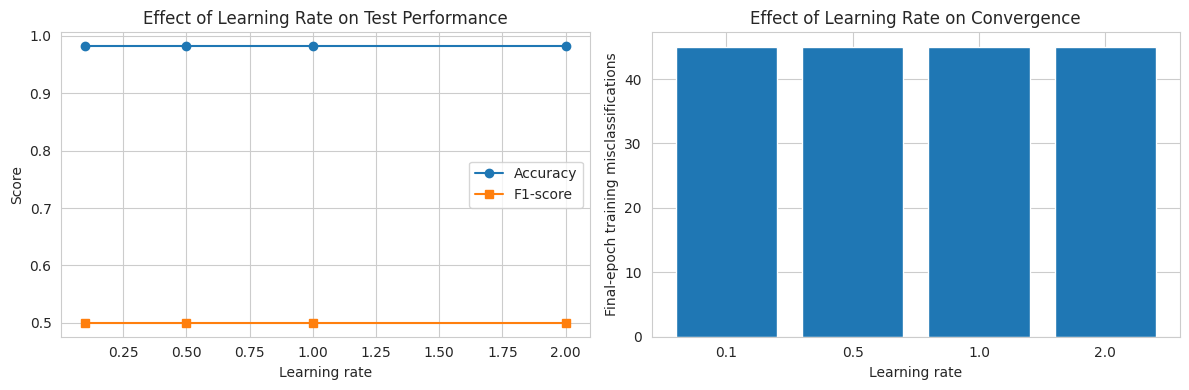

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(param_df["learning_rate"], param_df["accuracy"], marker="o", label="Accuracy")
axes[0].plot(param_df["learning_rate"], param_df["f1"], marker="s", label="F1-score")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Score")
axes[0].set_title("Effect of Learning Rate on Test Performance")
axes[0].legend()
axes[0].grid(True)

axes[1].bar(param_df["learning_rate"].astype(str), param_df["final_train_errors"])
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Final-epoch training misclassifications")
axes[1].set_title("Effect of Learning Rate on Convergence")

plt.tight_layout()
plt.show()